<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/RandomForest_Preprocessing_ModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, classification_report, confusion_matrix, make_scorer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import joblib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load and copy dataset
file_path = '/content/drive/MyDrive/Customer_Churn_Data.csv'
data = pd.read_csv(file_path)
df_rf = data.copy()

## Data Preprocessing

In [5]:
# TotalCharges: numeric conversion & imputation
df_rf['TotalCharges_numeric'] = pd.to_numeric(df_rf['TotalCharges'], errors='coerce')

# Calculate mean difference for missing values
mask_non_missing = df_rf['TotalCharges_numeric'].notna()
df_rf['calc_total'] = df_rf['MonthlyCharges'] * df_rf['tenure']
df_rf['diff'] = df_rf['TotalCharges_numeric'] - df_rf['calc_total']
mean_diff = df_rf.loc[mask_non_missing, 'diff'].mean()

# Impute missing values
mask_missing = df_rf['TotalCharges_numeric'].isna()
df_rf.loc[mask_missing, 'TotalCharges_numeric'] = (
    df_rf.loc[mask_missing, 'MonthlyCharges'] * df_rf.loc[mask_missing, 'tenure'] + mean_diff
)

# Drop helper columns and original TotalCharges
df_rf.drop(columns=['TotalCharges', 'calc_total', 'diff'], inplace=True)

In [6]:
# Drop irrelevant columns
df_rf.drop(columns=['customerID'], inplace=True)

In [7]:
# Encode categorical features
categorical_columns = df_rf.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_columns:
    categorical_columns.remove('Churn')

le = LabelEncoder()
for col in categorical_columns:
    df_rf[col] = le.fit_transform(df_rf[col].astype(str)).astype(int)

# Encode target separately
df_rf['Churn'] = df_rf['Churn'].str.strip().map({'No': 0, 'Yes': 1})

### Function: Split + SMOTE

In [8]:
def split_and_apply_smote(df, target_col='Churn', test_size=0.2, random_state=42):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    smote = SMOTE(random_state=random_state)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("X_train shape:", X_train_res.shape)
    print("X_test shape:", X_test.shape)
    print("y_train distribution after SMOTE:\n", y_train_res.value_counts(normalize=True))
    print("y_test distribution:\n", y_test.value_counts(normalize=True))

    return X_train_res, X_test, y_train_res, y_test

### Function: Hyperparameter tuning

In [32]:
def random_forest_random_search(X_train, y_train, param_distributions=None, n_iter=50, cv_splits=5, random_state=42):
    if param_distributions is None:
        param_distributions = {
            'n_estimators': [100, 150, 200],
            'max_depth': [10, 12, 15],
            'min_samples_split': [10, 20],
            'min_samples_leaf': [5, 10, 15],
            'max_features': ['sqrt'],
            'criterion': ['gini'],
            'bootstrap': [True],
            'class_weight': ['balanced']
        }

    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    f1_scorer = make_scorer(f1_score)

    random_search = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=random_state),
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=f1_scorer,
        cv=skf,
        n_jobs=-1,
        verbose=1,
        random_state=random_state
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score (CV):", random_search.best_score_)

    return random_search.best_estimator_, random_search

### Train model & threshold tuning

In [28]:
def train_random_forest(X_train_res, y_train_res, X_test, y_test, model_params=None,
                        threshold_start=0.1, threshold_stop=0.7, threshold_step=0.01, random_state=42):
    if model_params is None:
        model_params = grid_rf.best_params_ if grid_rf else {}
        model_params['random_state'] = random_state

    model = RandomForestClassifier(**model_params)
    model.fit(X_train_res, y_train_res)

    # Threshold tuning
    test_prob = model.predict_proba(X_test)[:,1]
    best_f1 = 0
    best_threshold = 0.5
    for threshold in np.arange(threshold_start, threshold_stop, threshold_step):
        test_pred = (test_prob >= threshold).astype(int)
        f1 = f1_score(y_test, test_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print("Best Threshold:", best_threshold)
    return model, best_threshold

### Evaluation Function

In [12]:
def evaluate_model(model, X_train_res, y_train_res, X_test, y_test, best_threshold):
    def evaluate_dataset(X, y, dataset_name="Test"):
        y_prob = model.predict_proba(X)[:,1]
        y_pred = (y_prob >= best_threshold).astype(int)
        acc = accuracy_score(y, y_pred)
        rec = recall_score(y, y_pred)
        prec = precision_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        roc = roc_auc_score(y, y_prob)
        print(f"\n--- {dataset_name} Evaluation ---")
        print(f"Accuracy: {acc:.4f}, Recall: {rec:.4f}, Precision: {prec:.4f}, F1: {f1:.4f}, AUC: {roc:.4f}")
        print("Classification Report:\n", classification_report(y, y_pred, digits=4))

        cm = confusion_matrix(y, y_pred)
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - {dataset_name}")
        plt.show()

        fpr, tpr, _ = roc_curve(y, y_prob)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc:.4f})', color='#fcbf49', lw=2)
        plt.plot([0,1],[0,1],'k--', lw=1.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {dataset_name}")
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()

        return acc, rec, prec, f1, roc

    print("\n--- Train Set Metrics ---")
    train_metrics = evaluate_dataset(X_train_res, y_train_res, "Train")
    print("\n--- Test Set Metrics ---")
    test_metrics = evaluate_dataset(X_test, y_test, "Test")

    # Feature Importance
    feature_importance = pd.DataFrame({
        'Feature': X_train_res.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    feature_importance['LogImportance'] = np.log1p(feature_importance['Importance'])
    plt.figure(figsize=(10,6))
    sns.barplot(x='LogImportance', y='Feature', data=feature_importance, palette="viridis")
    plt.xlabel("Log(Importance + 1)")
    plt.title("Feature Importance (Log-Transformed)")
    plt.show()

    return train_metrics, test_metrics

In [13]:
# Split dataset
X_train_res, X_test, y_train_res, y_test = split_and_apply_smote(df_rf)

X_train shape: (8278, 19)
X_test shape: (1409, 19)
y_train distribution after SMOTE:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [33]:
# Perform GridSearch
best_rf, grid_rf = random_forest_random_search(X_train_res, y_train_res, n_iter=50, cv_splits=5)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}
Best F1 Score (CV): 0.8476618652626815


In [34]:
# Train Random Forest
rf_model, best_threshold = train_random_forest(X_train_res, y_train_res, X_test, y_test)

Best Threshold: 0.3999999999999998



--- Train Set Metrics ---

--- Train Evaluation ---
Accuracy: 0.8851, Recall: 0.9570, Precision: 0.8367, F1: 0.8928, AUC: 0.9674
Classification Report:
               precision    recall  f1-score   support

           0     0.9498    0.8132    0.8762      4139
           1     0.8367    0.9570    0.8928      4139

    accuracy                         0.8851      8278
   macro avg     0.8932    0.8851    0.8845      8278
weighted avg     0.8932    0.8851    0.8845      8278



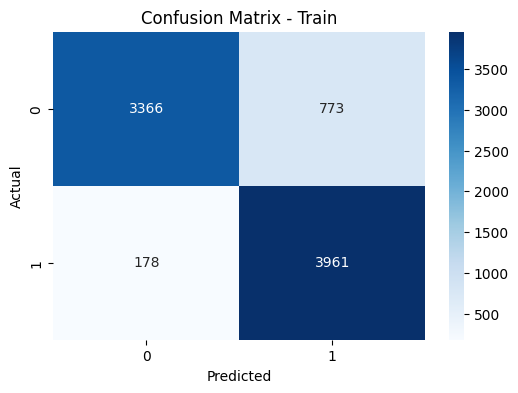

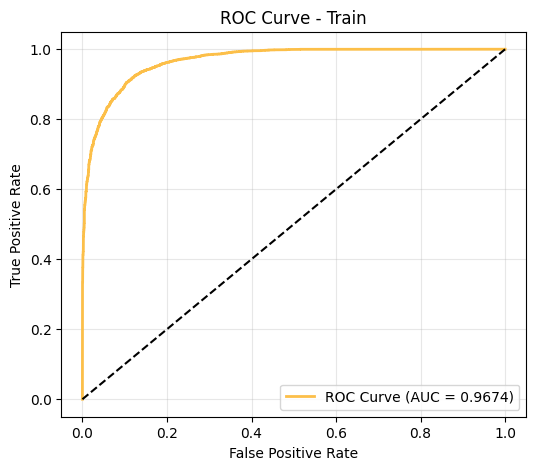


--- Test Set Metrics ---

--- Test Evaluation ---
Accuracy: 0.7544, Recall: 0.7647, Precision: 0.5257, F1: 0.6231, AUC: 0.8336
Classification Report:
               precision    recall  f1-score   support

           0     0.8983    0.7507    0.8179      1035
           1     0.5257    0.7647    0.6231       374

    accuracy                         0.7544      1409
   macro avg     0.7120    0.7577    0.7205      1409
weighted avg     0.7994    0.7544    0.7662      1409



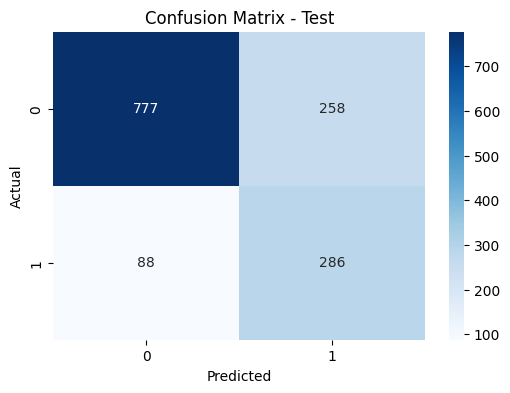

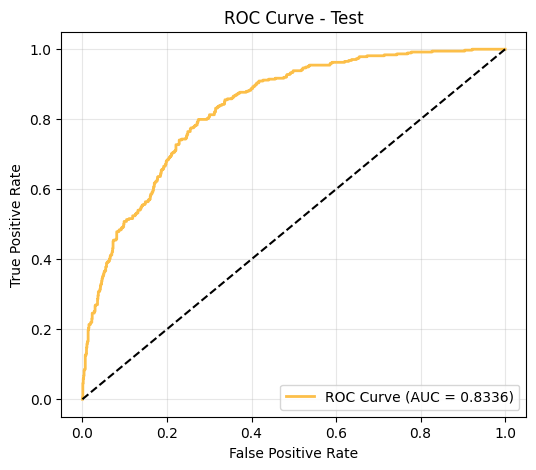

/tmp/ipykernel_169/1113587486.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LogImportance', y='Feature', data=feature_importance, palette="viridis")


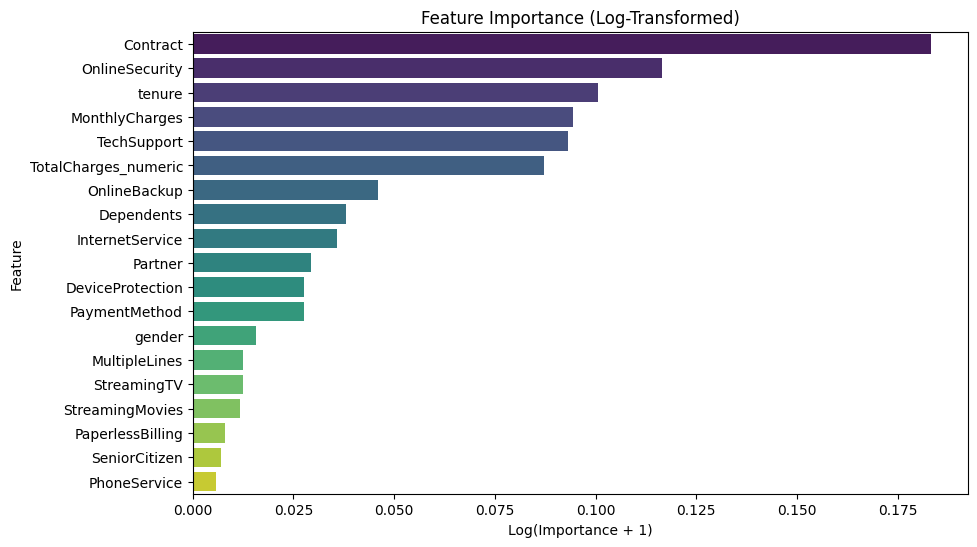

In [35]:
# Evaluate Random Forest
train_metrics, test_metrics = evaluate_model(rf_model, X_train_res, y_train_res, X_test, y_test, best_threshold)

In [ ]:
# Save Model & Threshold
joblib.dump(rf_model, '/content/drive/MyDrive/RF_Model/rf_model_final.pkl')
joblib.dump(best_threshold, '/content/drive/MyDrive/RF_Model/best_threshold.pkl')
print("Random Forest model and threshold saved successfully!")